In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from hydra.utils import instantiate
from omegaconf import OmegaConf


In [5]:
REPO = Path("/scratch2/ij292/tnp-crps")
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "external/tnp"))

cfg = OmegaConf.load(REPO / "experiments/configs/generators/sawtooth_1d.yml")
OmegaConf.resolve(cfg)

Seed set to 0


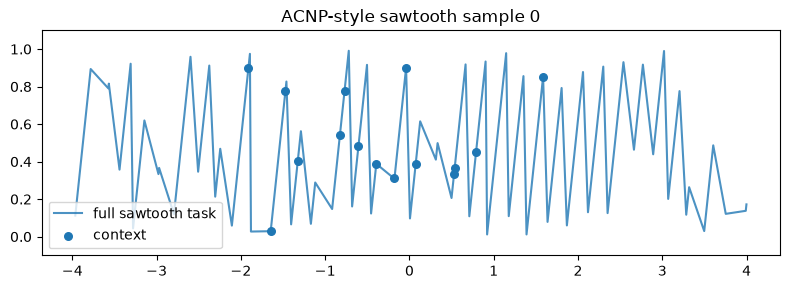

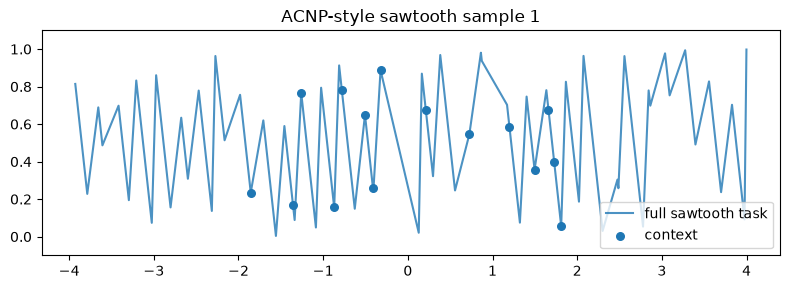

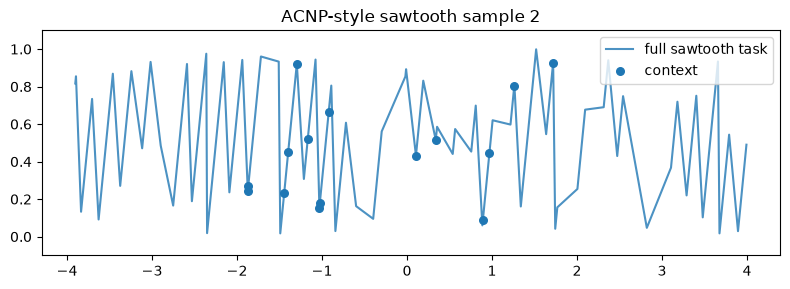

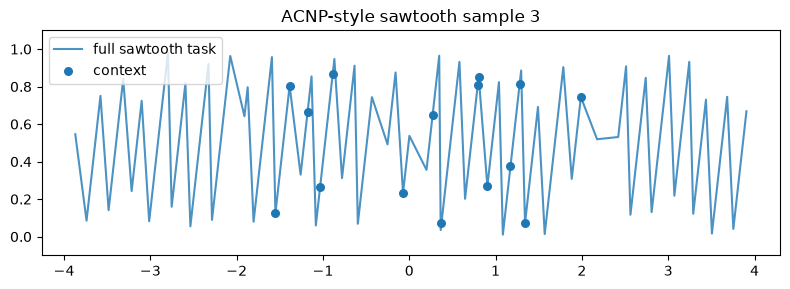

In [6]:
gen = instantiate(cfg.generators.test)
batch = next(iter(gen))

for i in range(4):
    x = batch.x[i, :, 0].cpu()
    y = batch.y[i, :, 0].cpu()
    xc = batch.xc[i, :, 0].cpu()
    yc = batch.yc[i, :, 0].cpu()

    order = x.argsort()

    plt.figure(figsize=(8, 3))
    plt.plot(x[order], y[order], alpha=0.8, label="full sawtooth task")
    plt.scatter(xc, yc, s=30, label="context", zorder=3)
    plt.title(f"ACNP-style sawtooth sample {i}")
    plt.ylim(-0.1, 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()